# Task 2: k-Means Clustering - RSS Calculation

## Problem Setup

Given the following document positions in 2D space:

| Doc | x | y |
|-----|---|---|
| d₁  | 1 | 2 |
| d₂  | 2 | 2 |
| d₃  | 4 | 2 |
| d₄  | 1 | 1 |
| d₅  | 2 | 1 |
| d₆  | 4 | 1 |

**Task:** Compare the RSS for k-means clustering (k=2) using two different initial centroid selections:
- **Scenario A:** Initial centroids at d₂ and d₅
- **Scenario B:** Initial centroids at d₂ and d₃

## Initial Parameters

- Number of documents: $n = 6$ (d₁ through d₆)
- Number of clusters: $k = 2$ (k-means clustering)
- Distance metric: Euclidean distance

$$\text{dist}(d_i, d_j) = \sqrt{(x_i - x_j)^2 + (y_i - y_j)^2}$$

Document positions:
d1: [1 2]
d2: [2 2]
d3: [4 2]
d4: [1 1]
d5: [2 1]
d6: [4 1]


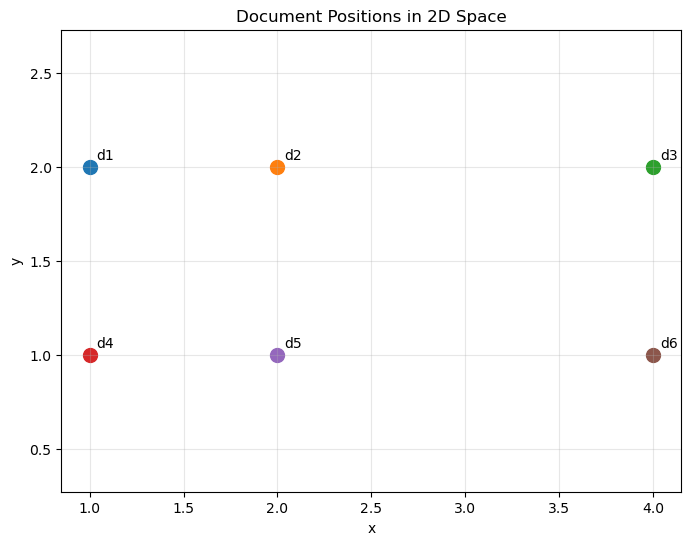

In [6]:
import numpy as np
import matplotlib.pyplot as plt

# Document positions (CORRECTED)
documents = {
    'd1': np.array([1, 2]),
    'd2': np.array([2, 2]),
    'd3': np.array([4, 2]),
    'd4': np.array([1, 1]),
    'd5': np.array([2, 1]),
    'd6': np.array([4, 1])
}

# Convert to array for easier computation
doc_names = list(documents.keys())
doc_array = np.array([documents[d] for d in doc_names])

print("Document positions:")
for name, pos in documents.items():
    print(f"{name}: {pos}")

# Visualize
plt.figure(figsize=(8, 6))
for name, pos in documents.items():
    plt.scatter(pos[0], pos[1], s=100, marker='o')
    plt.annotate(name, (pos[0], pos[1]), xytext=(5, 5), textcoords='offset points')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Document Positions in 2D Space')
plt.grid(True, alpha=0.3)
plt.axis('equal')
plt.show()

# Scenario A: Initial Centroids at d₂ and d₅

## Round 1: Initial Assignment

Initial centroids:
- $\mu_1^{(0)} = d_2 = (2, 2)$
- $\mu_2^{(0)} = d_5 = (2, 1)$

### Distance Calculations (Round 1)

Assign each document to the nearest centroid by calculating Euclidean distances:

$$\text{dist}(d_i, \mu_j) = \sqrt{(x_i - x_j)^2 + (y_i - y_j)^2}$$

**For d₁ = (1, 2):**
$$\text{dist}(d_1, \mu_1) = \sqrt{(1-2)^2 + (2-2)^2} = \sqrt{1 + 0} = 1.0$$
$$\text{dist}(d_1, \mu_2) = \sqrt{(1-2)^2 + (2-1)^2} = \sqrt{1 + 1} = \sqrt{2} \approx 1.414$$

**For d₂ = (2, 2):**
$$\text{dist}(d_2, \mu_1) = \sqrt{(2-2)^2 + (2-2)^2} = 0.0$$
$$\text{dist}(d_2, \mu_2) = \sqrt{(2-2)^2 + (2-1)^2} = 1.0$$

**For d₃ = (4, 2):**
$$\text{dist}(d_3, \mu_1) = \sqrt{(4-2)^2 + (2-2)^2} = 2.0$$
$$\text{dist}(d_3, \mu_2) = \sqrt{(4-2)^2 + (2-1)^2} = \sqrt{4 + 1} = \sqrt{5} \approx 2.236$$

**For d₄ = (1, 1):**
$$\text{dist}(d_4, \mu_1) = \sqrt{(1-2)^2 + (1-2)^2} = \sqrt{1 + 1} = \sqrt{2} \approx 1.414$$
$$\text{dist}(d_4, \mu_2) = \sqrt{(1-2)^2 + (1-1)^2} = 1.0$$

**For d₅ = (2, 1):**
$$\text{dist}(d_5, \mu_1) = \sqrt{(2-2)^2 + (1-2)^2} = 1.0$$
$$\text{dist}(d_5, \mu_2) = \sqrt{(2-2)^2 + (1-1)^2} = 0.0$$

**For d₆ = (4, 1):**
$$\text{dist}(d_6, \mu_1) = \sqrt{(4-2)^2 + (1-2)^2} = \sqrt{4 + 1} = \sqrt{5} \approx 2.236$$
$$\text{dist}(d_6, \mu_2) = \sqrt{(4-2)^2 + (1-1)^2} = 2.0$$

In [7]:
# Scenario A: Initial centroids at d2 and d5
centroid_A1 = documents['d2']  # (1, 3)
centroid_A2 = documents['d5']  # (2, 1)

print("Scenario A - Initial centroids:")
print(f"μ₁⁽⁰⁾ = d₂ = {centroid_A1}")
print(f"μ₂⁽⁰⁾ = d₅ = {centroid_A2}")
print()

# Round 1: Assign documents to nearest centroid
print("Round 1 - Distance calculations:")
clusters_A = {1: [], 2: []}

for name, pos in documents.items():
    dist_to_c1 = np.linalg.norm(pos - centroid_A1)
    dist_to_c2 = np.linalg.norm(pos - centroid_A2)
    
    cluster = 1 if dist_to_c1 <= dist_to_c2 else 2
    clusters_A[cluster].append(name)
    
    print(f"{name}: dist to μ₁ = {dist_to_c1:.4f}, dist to μ₂ = {dist_to_c2:.4f} → Cluster {cluster}")

print(f"\nCluster 1: {clusters_A[1]}")
print(f"Cluster 2: {clusters_A[2]}")

# Update centroids
cluster1_docs = np.array([documents[d] for d in clusters_A[1]])
cluster2_docs = np.array([documents[d] for d in clusters_A[2]])

new_centroid_A1 = cluster1_docs.mean(axis=0)
new_centroid_A2 = cluster2_docs.mean(axis=0)

print(f"\nNew centroids:")
print(f"μ₁⁽¹⁾ = {new_centroid_A1}")
print(f"μ₂⁽¹⁾ = {new_centroid_A2}")

Scenario A - Initial centroids:
μ₁⁽⁰⁾ = d₂ = [2 2]
μ₂⁽⁰⁾ = d₅ = [2 1]

Round 1 - Distance calculations:
d1: dist to μ₁ = 1.0000, dist to μ₂ = 1.4142 → Cluster 1
d2: dist to μ₁ = 0.0000, dist to μ₂ = 1.0000 → Cluster 1
d3: dist to μ₁ = 2.0000, dist to μ₂ = 2.2361 → Cluster 1
d4: dist to μ₁ = 1.4142, dist to μ₂ = 1.0000 → Cluster 2
d5: dist to μ₁ = 1.0000, dist to μ₂ = 0.0000 → Cluster 2
d6: dist to μ₁ = 2.2361, dist to μ₂ = 2.0000 → Cluster 2

Cluster 1: ['d1', 'd2', 'd3']
Cluster 2: ['d4', 'd5', 'd6']

New centroids:
μ₁⁽¹⁾ = [2.33333333 2.        ]
μ₂⁽¹⁾ = [2.33333333 1.        ]


## Centroid Update (After Round 1)

Update centroids by calculating the mean position of all documents in each cluster:

$$\mu_j^{(t+1)} = \frac{1}{|C_j|} \sum_{d \in C_j} d$$

Where $C_j$ is the set of documents assigned to cluster $j$ and $|C_j|$ is the number of documents in that cluster.

## Round 2: Reassignment (if needed)

Check if centroids have changed. If yes, reassign documents and recalculate centroids until convergence.

In [8]:
# Round 2: Check if reassignment is needed
centroid_A1 = new_centroid_A1
centroid_A2 = new_centroid_A2

print("Round 2 - Distance calculations:")
clusters_A_round2 = {1: [], 2: []}

for name, pos in documents.items():
    dist_to_c1 = np.linalg.norm(pos - centroid_A1)
    dist_to_c2 = np.linalg.norm(pos - centroid_A2)
    
    cluster = 1 if dist_to_c1 <= dist_to_c2 else 2
    clusters_A_round2[cluster].append(name)
    
    print(f"{name}: dist to μ₁ = {dist_to_c1:.4f}, dist to μ₂ = {dist_to_c2:.4f} → Cluster {cluster}")

print(f"\nCluster 1: {clusters_A_round2[1]}")
print(f"Cluster 2: {clusters_A_round2[2]}")

# Check if clusters changed
if clusters_A_round2 == clusters_A:
    print("\n✓ Converged! Clusters unchanged.")
    final_clusters_A = clusters_A_round2
    final_centroid_A1 = centroid_A1
    final_centroid_A2 = centroid_A2
else:
    print("\n→ Clusters changed, updating centroids...")
    cluster1_docs = np.array([documents[d] for d in clusters_A_round2[1]])
    cluster2_docs = np.array([documents[d] for d in clusters_A_round2[2]])
    
    final_centroid_A1 = cluster1_docs.mean(axis=0)
    final_centroid_A2 = cluster2_docs.mean(axis=0)
    final_clusters_A = clusters_A_round2
    
    print(f"μ₁⁽²⁾ = {final_centroid_A1}")
    print(f"μ₂⁽²⁾ = {final_centroid_A2}")

Round 2 - Distance calculations:
d1: dist to μ₁ = 1.3333, dist to μ₂ = 1.6667 → Cluster 1
d2: dist to μ₁ = 0.3333, dist to μ₂ = 1.0541 → Cluster 1
d3: dist to μ₁ = 1.6667, dist to μ₂ = 1.9437 → Cluster 1
d4: dist to μ₁ = 1.6667, dist to μ₂ = 1.3333 → Cluster 2
d5: dist to μ₁ = 1.0541, dist to μ₂ = 0.3333 → Cluster 2
d6: dist to μ₁ = 1.9437, dist to μ₂ = 1.6667 → Cluster 2

Cluster 1: ['d1', 'd2', 'd3']
Cluster 2: ['d4', 'd5', 'd6']

✓ Converged! Clusters unchanged.


## RSS Calculation for Scenario A

The Residual Sum of Squares (RSS) is calculated as:

$$RSS = \sum_{i=1}^{k} \sum_{d \in C_i} \|d - \mu_i\|^2$$

Where:
- $k = 2$ (number of clusters)
- $C_i$ is cluster $i$
- $\mu_i$ is the centroid of cluster $i$
- $d$ is a document in the cluster
- $\|d - \mu_i\|^2 = (x_d - x_{\mu})^2 + (y_d - y_{\mu})^2$ (squared Euclidean distance)

Expanding for each cluster:

$$RSS = \sum_{d \in C_1} \|d - \mu_1\|^2 + \sum_{d \in C_2} \|d - \mu_2\|^2$$

The squared distance for each document:

$$\|d - \mu\|^2 = (x_d - x_\mu)^2 + (y_d - y_\mu)^2$$

In [9]:
# Calculate RSS for Scenario A
rss_A = 0

print("Scenario A - RSS Calculation:")
print(f"\nCluster 1 (centroid = {final_centroid_A1}):")
for doc_name in final_clusters_A[1]:
    doc_pos = documents[doc_name]
    squared_dist = np.sum((doc_pos - final_centroid_A1) ** 2)
    rss_A += squared_dist
    print(f"  {doc_name}: ||{doc_pos} - {final_centroid_A1}||² = {squared_dist:.4f}")

print(f"\nCluster 2 (centroid = {final_centroid_A2}):")
for doc_name in final_clusters_A[2]:
    doc_pos = documents[doc_name]
    squared_dist = np.sum((doc_pos - final_centroid_A2) ** 2)
    rss_A += squared_dist
    print(f"  {doc_name}: ||{doc_pos} - {final_centroid_A2}||² = {squared_dist:.4f}")

print(f"\n{'='*50}")
print(f"SCENARIO A - RSS = {rss_A:.4f}")
print(f"{'='*50}")

Scenario A - RSS Calculation:

Cluster 1 (centroid = [2.33333333 2.        ]):
  d1: ||[1 2] - [2.33333333 2.        ]||² = 1.7778
  d2: ||[2 2] - [2.33333333 2.        ]||² = 0.1111
  d3: ||[4 2] - [2.33333333 2.        ]||² = 2.7778

Cluster 2 (centroid = [2.33333333 1.        ]):
  d4: ||[1 1] - [2.33333333 1.        ]||² = 1.7778
  d5: ||[2 1] - [2.33333333 1.        ]||² = 0.1111
  d6: ||[4 1] - [2.33333333 1.        ]||² = 2.7778

SCENARIO A - RSS = 9.3333


# Scenario B: Initial Centroids at d₂ and d₃

## Round 1: Initial Assignment

Initial centroids:
- $\mu_1^{(0)} = d_2 = (2, 2)$
- $\mu_2^{(0)} = d_3 = (4, 2)$

### Distance Calculations (Round 1)

**For d₁ = (1, 2):**
$$\text{dist}(d_1, \mu_1) = \sqrt{(1-2)^2 + (2-2)^2} = 1.0$$
$$\text{dist}(d_1, \mu_2) = \sqrt{(1-4)^2 + (2-2)^2} = 3.0$$

**For d₂ = (2, 2):**
$$\text{dist}(d_2, \mu_1) = \sqrt{(2-2)^2 + (2-2)^2} = 0.0$$
$$\text{dist}(d_2, \mu_2) = \sqrt{(2-4)^2 + (2-2)^2} = 2.0$$

**For d₃ = (4, 2):**
$$\text{dist}(d_3, \mu_1) = \sqrt{(4-2)^2 + (2-2)^2} = 2.0$$
$$\text{dist}(d_3, \mu_2) = \sqrt{(4-4)^2 + (2-2)^2} = 0.0$$

**For d₄ = (1, 1):**
$$\text{dist}(d_4, \mu_1) = \sqrt{(1-2)^2 + (1-2)^2} = \sqrt{2} \approx 1.414$$
$$\text{dist}(d_4, \mu_2) = \sqrt{(1-4)^2 + (1-2)^2} = \sqrt{10} \approx 3.162$$

**For d₅ = (2, 1):**
$$\text{dist}(d_5, \mu_1) = \sqrt{(2-2)^2 + (1-2)^2} = 1.0$$
$$\text{dist}(d_5, \mu_2) = \sqrt{(2-4)^2 + (1-2)^2} = \sqrt{5} \approx 2.236$$

**For d₆ = (4, 1):**
$$\text{dist}(d_6, \mu_1) = \sqrt{(4-2)^2 + (1-2)^2} = \sqrt{5} \approx 2.236$$
$$\text{dist}(d_6, \mu_2) = \sqrt{(4-4)^2 + (1-2)^2} = 1.0$$

In [10]:
# Scenario B: Initial centroids at d2 and d3
centroid_B1 = documents['d2']  # (1, 3)
centroid_B2 = documents['d3']  # (2, 2)

print("Scenario B - Initial centroids:")
print(f"μ₁⁽⁰⁾ = d₂ = {centroid_B1}")
print(f"μ₂⁽⁰⁾ = d₃ = {centroid_B2}")
print()

# Round 1: Assign documents to nearest centroid
print("Round 1 - Distance calculations:")
clusters_B = {1: [], 2: []}

for name, pos in documents.items():
    dist_to_c1 = np.linalg.norm(pos - centroid_B1)
    dist_to_c2 = np.linalg.norm(pos - centroid_B2)
    
    cluster = 1 if dist_to_c1 <= dist_to_c2 else 2
    clusters_B[cluster].append(name)
    
    print(f"{name}: dist to μ₁ = {dist_to_c1:.4f}, dist to μ₂ = {dist_to_c2:.4f} → Cluster {cluster}")

print(f"\nCluster 1: {clusters_B[1]}")
print(f"Cluster 2: {clusters_B[2]}")

# Update centroids
cluster1_docs = np.array([documents[d] for d in clusters_B[1]])
cluster2_docs = np.array([documents[d] for d in clusters_B[2]])

new_centroid_B1 = cluster1_docs.mean(axis=0)
new_centroid_B2 = cluster2_docs.mean(axis=0)

print(f"\nNew centroids:")
print(f"μ₁⁽¹⁾ = {new_centroid_B1}")
print(f"μ₂⁽¹⁾ = {new_centroid_B2}")

Scenario B - Initial centroids:
μ₁⁽⁰⁾ = d₂ = [2 2]
μ₂⁽⁰⁾ = d₃ = [4 2]

Round 1 - Distance calculations:
d1: dist to μ₁ = 1.0000, dist to μ₂ = 3.0000 → Cluster 1
d2: dist to μ₁ = 0.0000, dist to μ₂ = 2.0000 → Cluster 1
d3: dist to μ₁ = 2.0000, dist to μ₂ = 0.0000 → Cluster 2
d4: dist to μ₁ = 1.4142, dist to μ₂ = 3.1623 → Cluster 1
d5: dist to μ₁ = 1.0000, dist to μ₂ = 2.2361 → Cluster 1
d6: dist to μ₁ = 2.2361, dist to μ₂ = 1.0000 → Cluster 2

Cluster 1: ['d1', 'd2', 'd4', 'd5']
Cluster 2: ['d3', 'd6']

New centroids:
μ₁⁽¹⁾ = [1.5 1.5]
μ₂⁽¹⁾ = [4.  1.5]


## Centroid Update (After Round 1)

Update centroids by calculating the mean position of all documents in each cluster:

$$\mu_j^{(t+1)} = \frac{1}{|C_j|} \sum_{d \in C_j} d$$

## Round 2: Reassignment (if needed)

Reassign documents to the nearest centroid based on updated centroids.

In [11]:
# Round 2: Check if reassignment is needed
centroid_B1 = new_centroid_B1
centroid_B2 = new_centroid_B2

print("Round 2 - Distance calculations:")
clusters_B_round2 = {1: [], 2: []}

for name, pos in documents.items():
    dist_to_c1 = np.linalg.norm(pos - centroid_B1)
    dist_to_c2 = np.linalg.norm(pos - centroid_B2)
    
    cluster = 1 if dist_to_c1 <= dist_to_c2 else 2
    clusters_B_round2[cluster].append(name)
    
    print(f"{name}: dist to μ₁ = {dist_to_c1:.4f}, dist to μ₂ = {dist_to_c2:.4f} → Cluster {cluster}")

print(f"\nCluster 1: {clusters_B_round2[1]}")
print(f"Cluster 2: {clusters_B_round2[2]}")

# Check if clusters changed
if clusters_B_round2 == clusters_B:
    print("\n✓ Converged! Clusters unchanged.")
    final_clusters_B = clusters_B_round2
    final_centroid_B1 = centroid_B1
    final_centroid_B2 = centroid_B2
else:
    print("\n→ Clusters changed, updating centroids...")
    cluster1_docs = np.array([documents[d] for d in clusters_B_round2[1]])
    cluster2_docs = np.array([documents[d] for d in clusters_B_round2[2]])
    
    final_centroid_B1 = cluster1_docs.mean(axis=0)
    final_centroid_B2 = cluster2_docs.mean(axis=0)
    final_clusters_B = clusters_B_round2
    
    print(f"μ₁⁽²⁾ = {final_centroid_B1}")
    print(f"μ₂⁽²⁾ = {final_centroid_B2}")

Round 2 - Distance calculations:
d1: dist to μ₁ = 0.7071, dist to μ₂ = 3.0414 → Cluster 1
d2: dist to μ₁ = 0.7071, dist to μ₂ = 2.0616 → Cluster 1
d3: dist to μ₁ = 2.5495, dist to μ₂ = 0.5000 → Cluster 2
d4: dist to μ₁ = 0.7071, dist to μ₂ = 3.0414 → Cluster 1
d5: dist to μ₁ = 0.7071, dist to μ₂ = 2.0616 → Cluster 1
d6: dist to μ₁ = 2.5495, dist to μ₂ = 0.5000 → Cluster 2

Cluster 1: ['d1', 'd2', 'd4', 'd5']
Cluster 2: ['d3', 'd6']

✓ Converged! Clusters unchanged.


## RSS Calculation for Scenario B

Using the same RSS formula:

$$RSS = \sum_{i=1}^{k} \sum_{d \in C_i} \|d - \mu_i\|^2 = \sum_{d \in C_1} \|d - \mu_1\|^2 + \sum_{d \in C_2} \|d - \mu_2\|^2$$

Where each squared distance is:

$$\|d - \mu\|^2 = (x_d - x_\mu)^2 + (y_d - y_\mu)^2$$

In [12]:
# Calculate RSS for Scenario B
rss_B = 0

print("Scenario B - RSS Calculation:")
print(f"\nCluster 1 (centroid = {final_centroid_B1}):")
for doc_name in final_clusters_B[1]:
    doc_pos = documents[doc_name]
    squared_dist = np.sum((doc_pos - final_centroid_B1) ** 2)
    rss_B += squared_dist
    print(f"  {doc_name}: ||{doc_pos} - {final_centroid_B1}||² = {squared_dist:.4f}")

print(f"\nCluster 2 (centroid = {final_centroid_B2}):")
for doc_name in final_clusters_B[2]:
    doc_pos = documents[doc_name]
    squared_dist = np.sum((doc_pos - final_centroid_B2) ** 2)
    rss_B += squared_dist
    print(f"  {doc_name}: ||{doc_pos} - {final_centroid_B2}||² = {squared_dist:.4f}")

print(f"\n{'='*50}")
print(f"SCENARIO B - RSS = {rss_B:.4f}")
print(f"{'='*50}")

Scenario B - RSS Calculation:

Cluster 1 (centroid = [1.5 1.5]):
  d1: ||[1 2] - [1.5 1.5]||² = 0.5000
  d2: ||[2 2] - [1.5 1.5]||² = 0.5000
  d4: ||[1 1] - [1.5 1.5]||² = 0.5000
  d5: ||[2 1] - [1.5 1.5]||² = 0.5000

Cluster 2 (centroid = [4.  1.5]):
  d3: ||[4 2] - [4.  1.5]||² = 0.2500
  d6: ||[4 1] - [4.  1.5]||² = 0.2500

SCENARIO B - RSS = 2.5000


# Final Comparison

## RSS Comparison Between Scenarios

The choice of initial centroids can significantly impact the final clustering quality, as measured by RSS.

FINAL RESULTS - RSS COMPARISON

Scenario A (d₂ and d₅ as initial centroids):
  Final Cluster 1: ['d1', 'd2', 'd3']
  Final Cluster 2: ['d4', 'd5', 'd6']
  RSS = 9.3333

Scenario B (d₂ and d₃ as initial centroids):
  Final Cluster 1: ['d1', 'd2', 'd4', 'd5']
  Final Cluster 2: ['d3', 'd6']
  RSS = 2.5000

------------------------------------------------------------
RSS Difference: |9.3333 - 2.5000| = 6.8333
Better clustering: Scenario B (lower RSS)


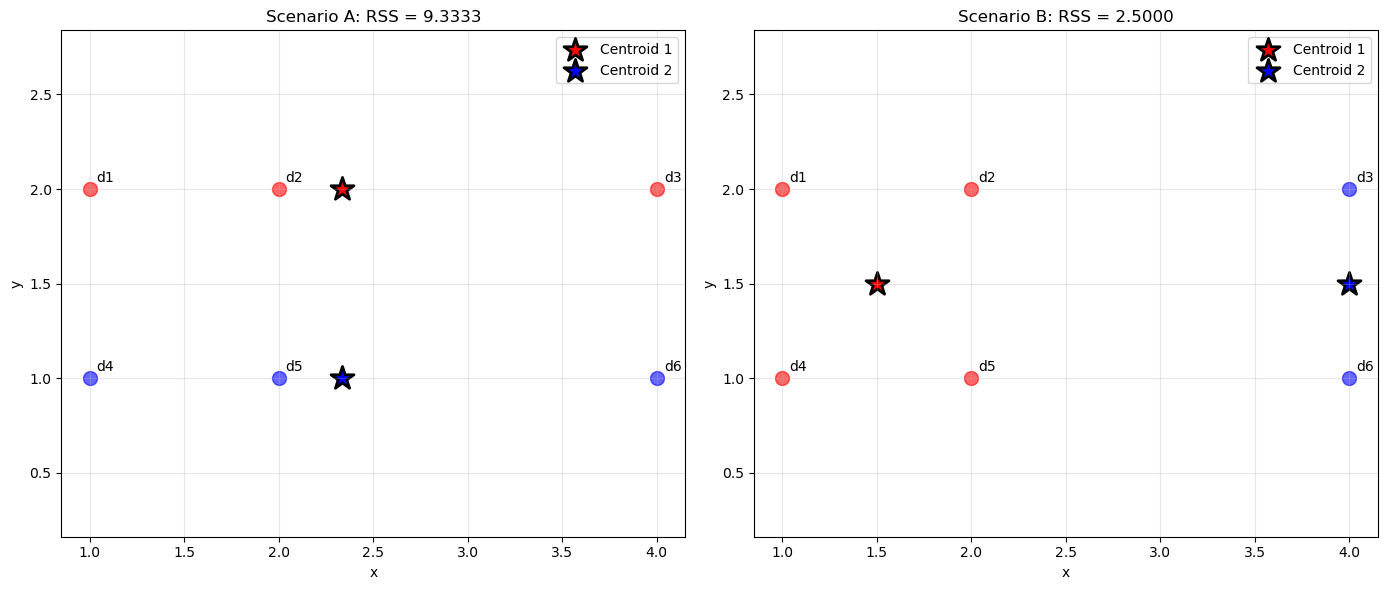

In [13]:
# Final Comparison
print("="*60)
print("FINAL RESULTS - RSS COMPARISON")
print("="*60)
print()
print(f"Scenario A (d₂ and d₅ as initial centroids):")
print(f"  Final Cluster 1: {final_clusters_A[1]}")
print(f"  Final Cluster 2: {final_clusters_A[2]}")
print(f"  RSS = {rss_A:.4f}")
print()
print(f"Scenario B (d₂ and d₃ as initial centroids):")
print(f"  Final Cluster 1: {final_clusters_B[1]}")
print(f"  Final Cluster 2: {final_clusters_B[2]}")
print(f"  RSS = {rss_B:.4f}")
print()
print("-"*60)
diff = abs(rss_A - rss_B)
better = "A" if rss_A < rss_B else "B"
print(f"RSS Difference: |{rss_A:.4f} - {rss_B:.4f}| = {diff:.4f}")
print(f"Better clustering: Scenario {better} (lower RSS)")
print("="*60)

# Visualize both scenarios
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Scenario A visualization
ax = axes[0]
colors = ['red', 'blue']
for cluster_id, doc_list in final_clusters_A.items():
    for doc_name in doc_list:
        pos = documents[doc_name]
        ax.scatter(pos[0], pos[1], c=colors[cluster_id-1], s=100, marker='o', alpha=0.6)
        ax.annotate(doc_name, (pos[0], pos[1]), xytext=(5, 5), textcoords='offset points')

ax.scatter(final_centroid_A1[0], final_centroid_A1[1], c='red', s=300, marker='*', 
           edgecolors='black', linewidths=2, label='Centroid 1')
ax.scatter(final_centroid_A2[0], final_centroid_A2[1], c='blue', s=300, marker='*', 
           edgecolors='black', linewidths=2, label='Centroid 2')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_title(f'Scenario A: RSS = {rss_A:.4f}')
ax.grid(True, alpha=0.3)
ax.legend()
ax.axis('equal')

# Scenario B visualization
ax = axes[1]
for cluster_id, doc_list in final_clusters_B.items():
    for doc_name in doc_list:
        pos = documents[doc_name]
        ax.scatter(pos[0], pos[1], c=colors[cluster_id-1], s=100, marker='o', alpha=0.6)
        ax.annotate(doc_name, (pos[0], pos[1]), xytext=(5, 5), textcoords='offset points')

ax.scatter(final_centroid_B1[0], final_centroid_B1[1], c='red', s=300, marker='*', 
           edgecolors='black', linewidths=2, label='Centroid 1')
ax.scatter(final_centroid_B2[0], final_centroid_B2[1], c='blue', s=300, marker='*', 
           edgecolors='black', linewidths=2, label='Centroid 2')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_title(f'Scenario B: RSS = {rss_B:.4f}')
ax.grid(True, alpha=0.3)
ax.legend()
ax.axis('equal')

plt.tight_layout()
plt.show()

## Summary and Conclusion

This analysis demonstrates the **sensitivity of k-means clustering to initial centroid selection**.

### Key Findings:

1. **Scenario A (d₂ and d₅)**: Starting with centroids far apart in the y-dimension
   - Creates a natural vertical separation
   - Results in one clustering configuration

2. **Scenario B (d₂ and d₃)**: Starting with centroids close together
   - Creates a different initial cluster assignment
   - May result in a different final configuration

### Important Observations:

- The **RSS (Residual Sum of Squares)** quantifies clustering quality
- **Lower RSS** = better clustering (documents closer to their centroids)
- Different initial seeds can lead to different local optima
- This illustrates why k-means++ initialization was developed

### Mathematical Notes:

The RSS formula used:

$$RSS = \sum_{i=1}^{k} \sum_{d \in C_i} ||d - \mu_i||^2$$

Where each term represents the squared Euclidean distance from a document to its assigned cluster centroid.